# 14b - Within-window readmission models (30/60/90)
Three yes/no models: readmitted within 30, 60, 90 days of first discharge.
5-fold CV for stable AUROC, threshold tuned on CV (not test), all five metrics.
Reads `patient_first_visit.csv`. Rationale: `docs/notebook_design_notes.md`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve)
from xgboost import XGBClassifier

DATA_DIR = "/Users/robert/Desktop/hospital-re-admission/data/processed"
RESULTS_DIR = "/Users/robert/Desktop/hospital-re-admission/notebooks/14_patient_models"
SEED = 42

## Load and encode
One row per patient. Categoricals label-encoded on train only.
Patient-level split from NB13.

In [2]:
df = pd.read_csv(f"{DATA_DIR}/patient_first_visit.csv")
drop_cols = ["subject_id", "hadm_id", "tgt_bucket", "tgt_days", "visit_num", "split"]
cat_cols = ["gender", "race", "marital_status", "language", "insurance",
            "admission_type", "admission_location", "discharge_location"]
features = [c for c in df.columns if c not in drop_cols]

is_train = df["split"].values == "train"
X = df[features].copy()
for c in cat_cols:
    mapping = {v: i for i, v in enumerate(sorted(X.loc[is_train, c].astype(str).unique()))}
    X[c] = X[c].astype(str).map(mapping).fillna(-1).astype(int)
Xtr = X[is_train].reset_index(drop=True)
Xte = X[~is_train].reset_index(drop=True)
print(f"train {len(Xtr):,}  test {len(Xte):,}  features {len(features)}")

train 144,281  test 36,071  features 46


## Train one model per window
For each window: cross-validate, pick the F1-best threshold on CV predictions,
retrain on all training data, then score on the untouched test set.

In [3]:
def new_model():
    return XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, subsample=0.8,
                         colsample_bytree=0.8, eval_metric="logloss", tree_method="hist",
                         random_state=SEED, n_jobs=4)

def evaluate_window(days_limit, name):
    y = (df["tgt_days"] <= days_limit).fillna(False).astype(int).values
    ytr, yte = y[is_train], y[~is_train]

    # 5-fold CV on train: out-of-fold probs (for threshold) + per-fold AUROC.
    skf = StratifiedKFold(5, shuffle=True, random_state=SEED)
    oof = np.zeros(len(ytr)); fold_auc = []
    for a, b in skf.split(Xtr, ytr):
        m = new_model()
        m.fit(Xtr.iloc[a], ytr[a], sample_weight=compute_sample_weight("balanced", ytr[a]))
        oof[b] = m.predict_proba(Xtr.iloc[b])[:, 1]
        fold_auc.append(roc_auc_score(ytr[b], oof[b]))

    thresholds = np.linspace(0.1, 0.9, 33)
    thr = max(thresholds, key=lambda t: f1_score(ytr, (oof >= t).astype(int), zero_division=0))

    # Retrain on all train, score on test at the CV-chosen threshold.
    m = new_model()
    m.fit(Xtr, ytr, sample_weight=compute_sample_weight("balanced", ytr))
    proba = m.predict_proba(Xte)[:, 1]
    pred = (proba >= thr).astype(int)
    return {
        "window": name,
        "cv_auroc": round(np.mean(fold_auc), 3),
        "cv_auroc_std": round(np.std(fold_auc), 3),
        "threshold": round(thr, 2),
        "accuracy": round(accuracy_score(yte, pred), 3),
        "precision": round(precision_score(yte, pred, zero_division=0), 3),
        "recall": round(recall_score(yte, pred, zero_division=0), 3),
        "f1": round(f1_score(yte, pred, zero_division=0), 3),
        "test_auroc": round(roc_auc_score(yte, proba), 3),
    }, (yte, proba)

results, roc_data = [], {}
for lim, nm in [(30, "within 30d"), (60, "within 60d"), (90, "within 90d")]:
    r, rc = evaluate_window(lim, nm)
    results.append(r); roc_data[nm] = rc

summary = pd.DataFrame(results)
print(summary.to_string(index=False))
summary.to_csv(f"{RESULTS_DIR}/14b_window_scores.csv", index=False)

    window  cv_auroc  cv_auroc_std  threshold  accuracy  precision  recall    f1  test_auroc
within 30d     0.678         0.002       0.52     0.739      0.222   0.466 0.301       0.682
within 60d     0.689         0.001       0.50     0.685      0.266   0.568 0.362       0.694
within 90d     0.692         0.004       0.50     0.679      0.297   0.578 0.393       0.699


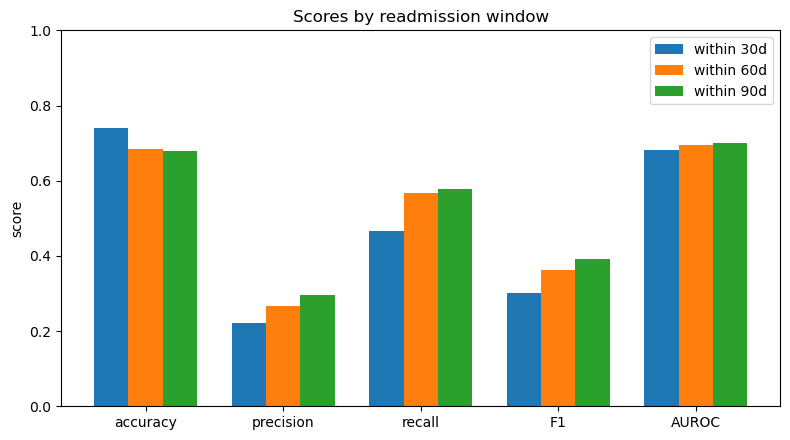

In [4]:
# Graph: all five metrics side by side for the three windows.
metrics = ["accuracy", "precision", "recall", "f1", "test_auroc"]
labels = ["accuracy", "precision", "recall", "F1", "AUROC"]
x = np.arange(len(metrics)); w = 0.25
fig, ax = plt.subplots(figsize=(8, 4.5))
for i, r in enumerate(results):
    ax.bar(x + (i - 1) * w, [r[m] for m in metrics], w, label=r["window"])
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0, 1); ax.set_ylabel("score"); ax.legend()
ax.set_title("Scores by readmission window")
plt.tight_layout(); plt.savefig(f"{RESULTS_DIR}/14b_scores_by_window.png", dpi=150); plt.show()

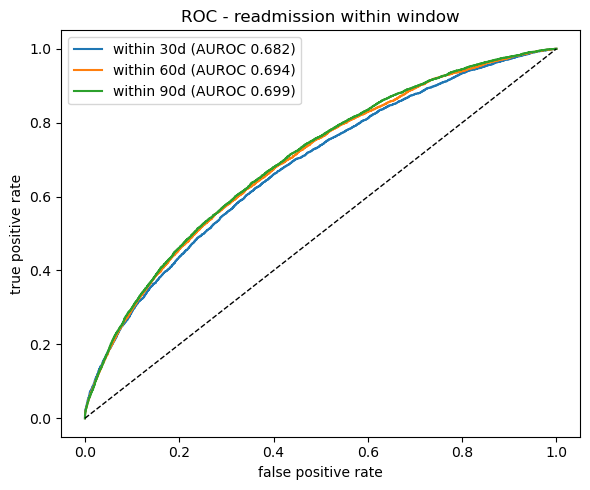

In [5]:
# Graph: ROC curves for the three windows.
fig, ax = plt.subplots(figsize=(6, 5))
for nm, (yte, proba) in roc_data.items():
    fpr, tpr, _ = roc_curve(yte, proba)
    ax.plot(fpr, tpr, label=f"{nm} (AUROC {roc_auc_score(yte, proba):.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1)
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")
ax.set_title("ROC - readmission within window"); ax.legend()
plt.tight_layout(); plt.savefig(f"{RESULTS_DIR}/14b_roc_curves.png", dpi=150); plt.show()